In [1]:
import pandas as pd
stats_df = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/AGeneratefulldf/GEV_station_variable_timeseries.csv")

In [2]:
stats_df

,station,block_time,extract_time,u10,v10,d2m,t2m,msl,sst,sp,...,wind_dir,u10_abs,v10_abs,wind_wave_diff,wind_wave_alignment,tau_u,tau_v,tau_mag,lat,lon
0,1,1952-09-30,1952-09-30 12:00:00,1.054550,-3.109146,285.80115,287.14615,97898.440,286.74365,97670.660,...,161.264250,1.054550,3.109146,NaN,NaN,0.005506,-0.016234,0.017120,48.38300,-4.49500
1,1,1952-11-30,1952-11-27 17:00:00,10.697113,5.936523,281.93515,283.97467,98755.310,284.99340,98523.470,...,60.971256,10.697113,5.936523,NaN,NaN,1.081795,0.600358,6.422099,48.38300,-4.49500
2,1,1953-01-31,1952-12-13 00:00:00,10.812012,-2.741409,277.67975,281.84796,99196.750,284.45825,98961.780,...,104.227630,10.812012,2.741409,NaN,NaN,0.510348,-0.129400,1.399073,48.38300,-4.49500
3,1,1953-03-31,1953-03-19 04:00:00,-5.420212,-1.598282,279.86240,282.07275,101696.810,282.92554,101457.300,...,253.570560,5.420212,1.598282,NaN,NaN,-0.074777,-0.022050,0.119514,48.38300,-4.49500
4,1,1953-05-31,1953-04-05 15:00:00,12.137955,5.498245,277.39224,282.04468,100337.000,283.03052,100099.940,...,65.630450,12.137955,5.498245,NaN,NaN,1.290015,0.584350,7.092817,48.38300,-4.49500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51007,99,2024-05-31,2024-04-09 05:00:00,9.501770,7.269272,278.27173,281.46628,100835.060,283.65210,100498.945,...,52.582420,9.501770,7.269272,195.45386,0.780636,1.045152,0.799587,7.597492,49.48378,0.11458
51008,99,2024-07-31,2024-07-06 05:00:00,10.395020,2.591583,286.51373,288.83830,100241.060,290.48486,99915.560,...,76.000970,10.395020,2.591583,178.57047,-0.877431,0.445959,0.111182,1.155741,49.48378,0.11458
51009,99,2024-09-30,2024-09-10 23:00:00,9.047180,-2.624329,287.52730,289.05844,100914.190,291.46167,100586.530,...,106.175930,9.047180,2.624329,178.04599,-0.519277,0.342077,-0.099227,0.897723,49.48378,0.11458
51010,99,2024-11-30,2024-11-25 07:00:00,3.672012,2.281738,281.09137,283.42220,100158.690,285.40650,99828.970,...,58.143745,3.672012,2.281738,189.90433,0.161320,0.048995,0.030445,0.111794,49.48378,0.11458


In [3]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --------------------------------------------------
# 1. START FROM stats_df
# --------------------------------------------------

# Ensure we are working on a copy
df = stats_df.copy()

# --------------------------------------------------
# 2. SELECT NUMERIC VARIABLES ONLY
#    (PCA is ONLY for continuous variables)
# --------------------------------------------------

numeric_df = df.select_dtypes(include=[np.number])

# Optional: drop identifiers if they slipped in
# (station is numeric but should not be in PCA)
if "station" in numeric_df.columns:
    numeric_df = numeric_df.drop(columns=["station"])


In [4]:
hallo

NameError: name 'hallo' is not defined

In [6]:
numeric_df["wind_mag"] = np.sqrt(numeric_df["u10"]**2 + numeric_df["v10"]**2)

In [7]:
metadata_cols = ["station", "block_time", "extract_time", "year", "residual_is_deviant", "residual", "tide"]

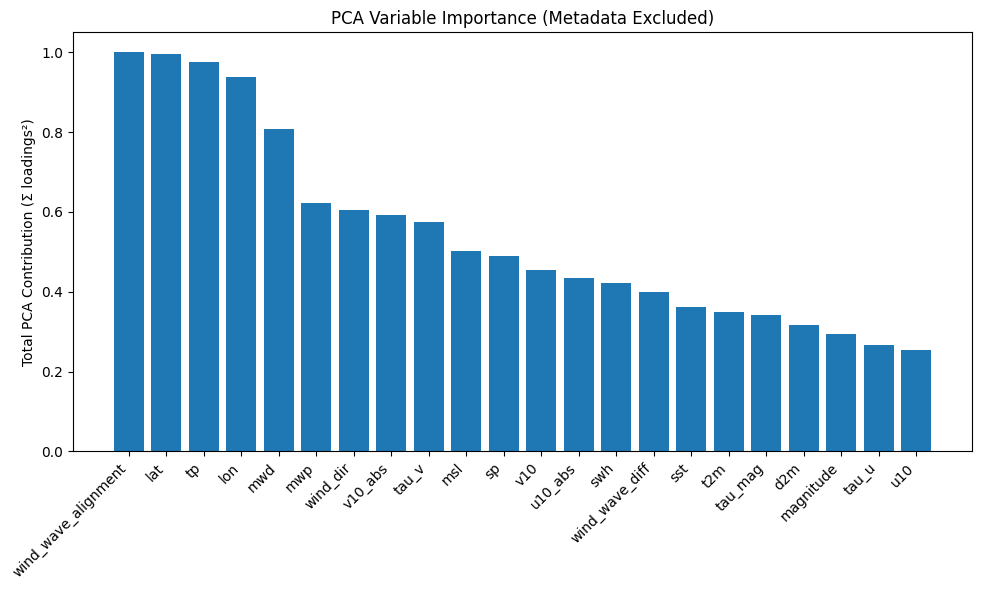

Variables used in PCA: 22
Retained PCs: 12
Cumulative variance explained: 0.953


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --------------------------------------------------
# 1. DEFINE METADATA COLUMNS (EXCLUDED FROM PCA)
# --------------------------------------------------

metadata_cols = [c for c in metadata_cols if c in stats_df.columns]

# --------------------------------------------------
# 2. SELECT PCA VARIABLES ONLY
# --------------------------------------------------

pca_df = stats_df.drop(columns=metadata_cols)

# Keep numeric variables only
pca_df = pca_df.select_dtypes(include=[np.number])

# Drop rows with missing values
pca_df = pca_df.dropna(axis=0)

# --------------------------------------------------
# 3. STANDARDIZE
# --------------------------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_df)

# --------------------------------------------------
# 4. FIT FULL PCA
# --------------------------------------------------

pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

# --------------------------------------------------
# 5. EXPLAINED VARIANCE TABLE
# --------------------------------------------------

explained_variance = pd.DataFrame(
    {
        "component": np.arange(1, len(pca_full.explained_variance_ratio_) + 1),
        "explained_variance_ratio": pca_full.explained_variance_ratio_,
        "cumulative_explained_variance": np.cumsum(
            pca_full.explained_variance_ratio_
        ),
    }
)

# --------------------------------------------------
# 6. SELECT COMPONENTS (95% VARIANCE)
# --------------------------------------------------

n_components = int(
    explained_variance.loc[
        explained_variance["cumulative_explained_variance"] >= 0.95,
        "component",
    ].iloc[0]
)

# --------------------------------------------------
# 7. REFIT PCA WITH REDUCED DIMENSION
# --------------------------------------------------

pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

# --------------------------------------------------
# 8. PCA SCORES
# --------------------------------------------------

pca_columns = [f"PC{i+1}" for i in range(n_components)]
pca_scores_df = pd.DataFrame(
    X_pca,
    columns=pca_columns,
    index=pca_df.index,
)

# --------------------------------------------------
# 9. LOADINGS
# --------------------------------------------------

loadings = pd.DataFrame(
    pca.components_.T,
    index=pca_df.columns,
    columns=pca_columns,
)

# --------------------------------------------------
# 10. VARIABLE IMPORTANCE (Σ loadings²)
# --------------------------------------------------

variable_importance = (loadings ** 2).sum(axis=1)
variable_importance = variable_importance.sort_values(ascending=False)

# --------------------------------------------------
# 11. PLOT: MOST → LEAST IMPORTANT VARIABLES
# --------------------------------------------------

plt.figure(figsize=(10, 6))
plt.bar(variable_importance.index, variable_importance.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Total PCA Contribution (Σ loadings²)")
plt.title("PCA Variable Importance (Metadata Excluded)")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 12. OPTIONAL: MERGE METADATA BACK
# --------------------------------------------------

final_pca_df = pd.concat(
    [
        stats_df.loc[pca_scores_df.index, metadata_cols],
        pca_scores_df,
    ],
    axis=1,
)

# --------------------------------------------------
# 13. SUMMARY
# --------------------------------------------------

print(f"Variables used in PCA: {pca_df.shape[1]}")
print(f"Retained PCs: {n_components}")
print(
    f"Cumulative variance explained: "
    f"{explained_variance.loc[n_components-1, 'cumulative_explained_variance']:.3f}"
)


In [9]:
selected_vars = variable_importance.cumsum()
selected_vars = selected_vars[selected_vars <= 0.8 * selected_vars.iloc[-1]].index

In [10]:
selected_vars.shape

(14,)

In [11]:
stats_df.columns

Index(['station', 'block_time', 'extract_time', 'u10', 'v10', 'd2m', 't2m',
       'msl', 'sst', 'sp', 'tp', 'mwd', 'mwp', 'swh', 'tide', 'residual',
       'residual_is_deviant', 'magnitude', 'wind_dir', 'u10_abs', 'v10_abs',
       'wind_wave_diff', 'wind_wave_alignment', 'tau_u', 'tau_v', 'tau_mag',
       'lat', 'lon'],
      dtype='object')

In [12]:
stats_df.columns

Index(['station', 'block_time', 'extract_time', 'u10', 'v10', 'd2m', 't2m',
       'msl', 'sst', 'sp', 'tp', 'mwd', 'mwp', 'swh', 'tide', 'residual',
       'residual_is_deviant', 'magnitude', 'wind_dir', 'u10_abs', 'v10_abs',
       'wind_wave_diff', 'wind_wave_alignment', 'tau_u', 'tau_v', 'tau_mag',
       'lat', 'lon'],
      dtype='object')

In [13]:
hoi = selected_vars.to_list()
hoi.append("station")
hoi.append("extract_time")
hoi.append("magnitude")
selected_df = stats_df[hoi]

In [18]:
selected_df.to_csv("pca_variables.csv")